In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
df = pd.read_excel(os.path.join(BASE_DIR, "../data/online_retail_II.xlsx"))

df = df.dropna(subset=["Customer ID", "Description"])
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]
df = df[df["Price"] < 100]  

print(df.shape)
print(df.dtypes)
print(df.describe())

(407489, 8)
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object
            Quantity                    InvoiceDate          Price  \
count  407489.000000                         407489  407489.000000   
mean       13.590956  2010-07-01 10:17:40.561978368       3.008567   
min         1.000000            2009-12-01 07:45:00       0.001000   
25%         2.000000            2010-03-26 14:01:00       1.250000   
50%         5.000000            2010-07-09 15:46:00       1.950000   
75%        12.000000            2010-10-14 17:09:00       3.750000   
max     19152.000000            2010-12-09 20:01:00      99.000000   
std        96.861193                            NaN       3.428975   

         Customer ID  
count  407489.000000  
mean    15368.979084  
min     12346.000000  
25%     139

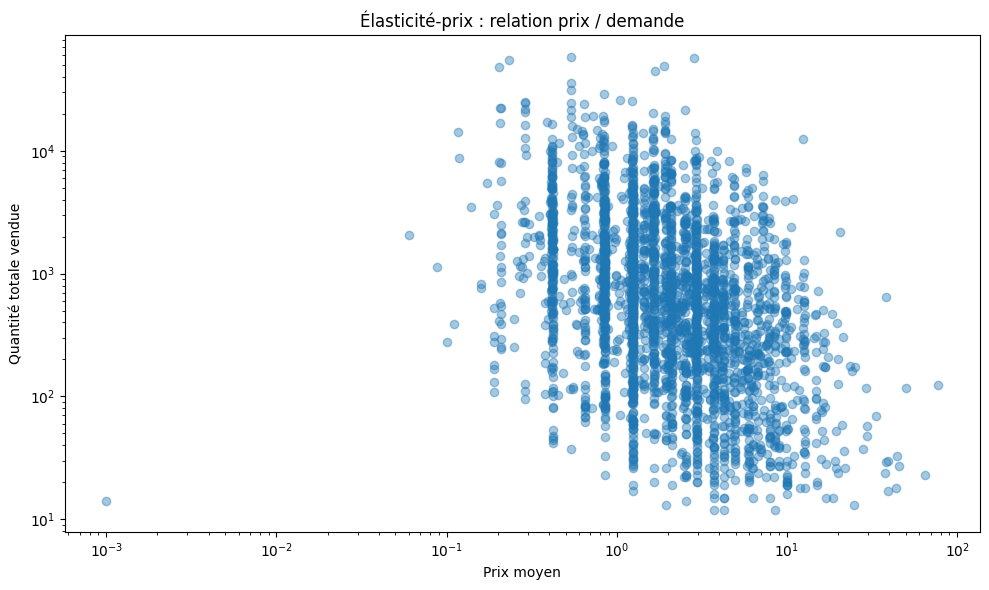

In [4]:
elasticity = df.groupby("StockCode").agg(
    avg_price=("Price", "mean"),
    total_qty=("Quantity", "sum"),
    n_transactions=("Invoice", "count")
).reset_index()

elasticity = elasticity[elasticity["n_transactions"] >= 10]

plt.figure(figsize=(10, 6))
plt.scatter(elasticity["avg_price"], elasticity["total_qty"], alpha=0.4)
plt.xlabel("Prix moyen")
plt.ylabel("Quantité totale vendue")
plt.title("Élasticité-prix : relation prix / demande")
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()

In [5]:
df["Month"] = pd.to_datetime(df["InvoiceDate"]).dt.month
df["DayOfWeek"] = pd.to_datetime(df["InvoiceDate"]).dt.dayofweek
df["Revenue"] = df["Price"] * df["Quantity"]

top_countries = df["Country"].value_counts().head(10).index
df["Country_enc"] = df["Country"].apply(lambda x: x if x in top_countries else "Other")
df = pd.get_dummies(df, columns=["Country_enc"])

print("Features créées avec succès")
print(df.head())

Features créées avec succès
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  Month  DayOfWeek  \
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom     12          1   
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     12          1   
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     12          1   
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom     12          1   
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom     12          1   

   ...  Country_enc_EIRE  Country_enc_France  Country_enc_Germany  \
0  ... 